# Meta Learners - Infant Development and Specialist Visits

In this notebook we use the meta-learer framework to estimate conditional average treatment effects (CATEs). The meta-learner frameworks leverage flexible machine learning models for the estimation of treatment effects in high dimensional settings where the functional form is unknown. We use the Infant Health and Development Program (IHDP) dataset. IHDP was originally a randomised controlled experiment studying the effectiveness of home visits on the cognitive development of premature, low-birth-weight infants. Hill (2011) made two modifications to the dataset making it the standard testbed for the estimation of HTEs: a nonrandom subset of the treated group was removed, so treatment assignment is confounded the way observational data is, and the outcomes are simulated from the real covariates – so both potential outcomes, and therefore every unit’s "true effect", are known. 

In this notebook I first introduce the idea of heterogenous treatment effects and link them to the dataset to make concrete what we are trying to achieve. We then load the data...

# Heterogenous Treatment Effects (HTEs)

A lot of times just knowing the average treatment effect of a treatment is not good enough, especially when there is a fixed cost to treating and our units are heterogenous (e.g. are humans). For example, a marketing department may find that when offering discounts some of the customers would have bought the product regardless of whether they received a discount (this is called leaving money on the table). The customers in this example displayed heterogenous treatment effects, they responded differently to the treatment. For some, the discount increased the probability of purchase and for others the probability was not changed.

$$
CATE = E[Y_{1} - Y_{0} | X]
$$

The formula above says the CATE is the expected difference between the outcome where treatment was received and not received given some value of the covariates $X$. We can think of this difference as a function of $X$, as we change the value of the covariates then the average difference in potential outcomes changes. That is the effect of the treatment depends upon the makeup of the unit being treated. 

However, as always in causal inference we have do not observe both potential outcomes. To get a sense of how we can get to an estimate of the CATE consider the following model

$$
y_{i} = \beta_{0} + \beta_{1}t_{i} + \bold{\beta_{2}X_{i}} + \beta_{3}t*\bold{X_{i}}
$$

If we differentiate with respect the treatment this tells us how the outcome changes with respect to the treatment and as we have the interaction term this derivative is dependent on the values of covariates and therefore we have some estimate of the CATE

$$
\frac{\partial{y}}{\partial{t}} = \beta_{1} + \bold{\beta_{3}}\bold{X_{i}}
$$

However, there can be many covariates in the vector $\bold{X_{i}}$ and a linear model or more generally a data model that we specify is unlikely to capture the true interaction between the covariates and the treatment. In the IHDP example we have 25 covariates which cover the child's measurement and the social/behavioural indicators about the mother, the treatment is binary and captures whether a child was subject to high-quality and intensive home visits and the outcome is the child's score on a cognitive test at age 3. In the context of this notebook we are interested in whether we can idenitfy groups of the covariates with different ATEs.

In [159]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from get_data import fetch_ihdp_data
from causalml.propensity import ElasticNetPropensityModel
import matplotlib.pyplot as plt
from causalml.inference import meta
from causalml.metrics import rate_score, plot_toc, rate_score
from xgboost import XGBRegressor
from sklearn.model_selection import StratifiedKFold, train_test_split

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [160]:
import warnings 
warnings.filterwarnings("ignore")

## Load Data

-- explain data and variables

In [220]:
RS = 42
np.random.seed(RS)

train = fetch_ihdp_data(replication=0, split="train")
test = fetch_ihdp_data(replication=0, split="test")
X_tr = pd.DataFrame(train.data, columns=train.feature_names)
w_tr, y_tr, tau_tr = train.treatment, train.target, train.tau
X_te = pd.DataFrame(test.data, columns=test.feature_names)
w_te, y_te, tau_te = test.treatment, test.target, test.tau

print(X_tr.shape, w_tr.sum(), X_te.shape, w_te.sum())
print("true ATE: %.3f | sd of tau: %.3f" % (tau_tr.mean(), tau_tr.std()))

(672, 25) 123 (75, 25) 16
true ATE: 4.012 | sd of tau: 0.866


## Indentification and Overlap

Before any estimation we should consider if we can identify any treatment effect from the data. We assume that treatment assignment is unconfounded given the covariates. This means that we can control for every variables which causes both treatment assignment and outcome. Every estimator we introduce below rests on this assumption. In this dataset this assumption is true by construction because the outcome was simulated from the covariates. In practice this is an untestable assumption.

The other requirement for identification is overlap. The treated group and the control group must have significant overlap across the covariates. When we translate this into a propensity score it means that every unit/group must have some positive probability of recieving treatment if this is true then both potential outcomes are represented in every point where we estimate the CATE meaning the model does not need to extrapolate. Unlike unconfoundedness assumption above we can check overlap assumption holds. The two distributions have significant overlap therefore estimation is possible. However, we do have poor overlap for some of treated group with a high probability of treatment and a spike in the control group with near zero propensity scores. 

In [221]:
prop_model = ElasticNetPropensityModel(Cs=np.logspace(0, 3, 8), random_state=RS)
prop_model.fit(X_tr, w_tr)

p_tr, p_te = prop_model.predict(X_tr), prop_model.predict(X_te)

print(np.sum(p_tr[w_tr==0] == 0))

0


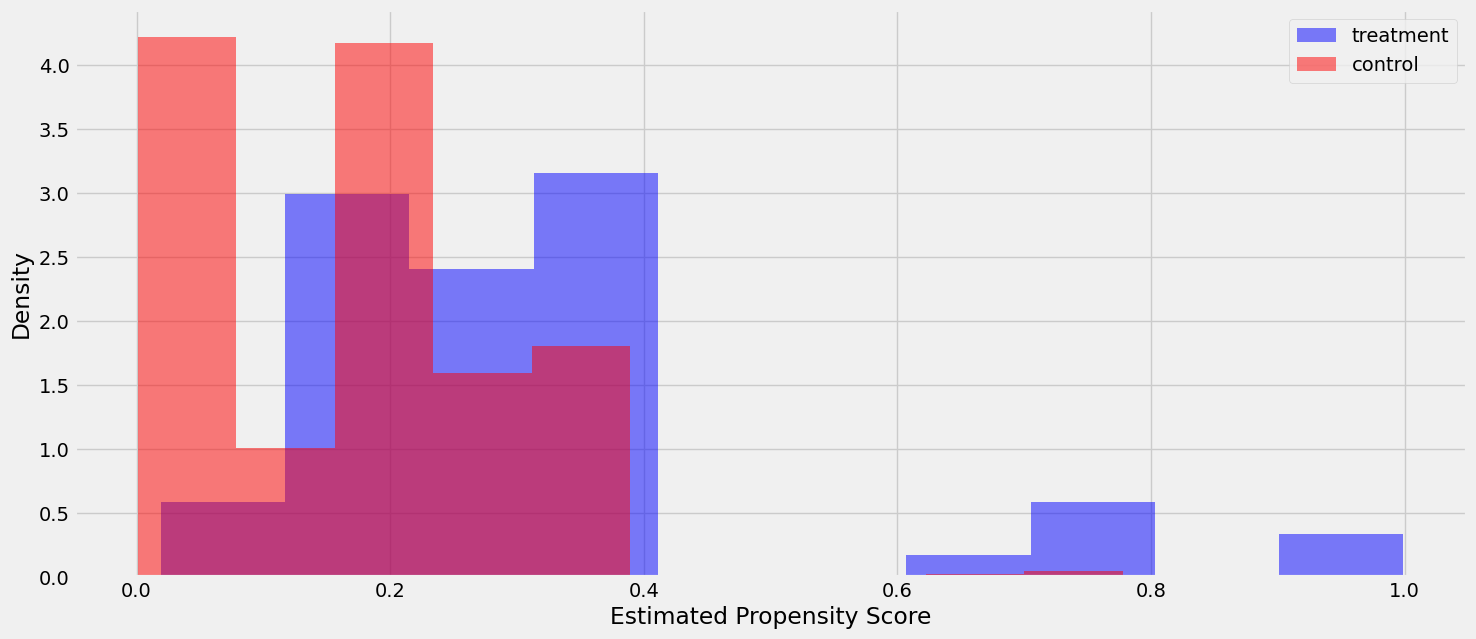

In [222]:
fig, ax = plt.subplots(1,1,figsize=(16,7))

ax.hist(p_tr[w_tr == 1], color='blue', alpha=0.5, label='treatment', density=True)
ax.hist(p_tr[w_tr == 0], color='red', alpha=0.5, label='control', density=True)
ax.set_xlabel('Estimated Propensity Score')
ax.set_ylabel('Density')
ax.legend()

## Linear Regression

Below we fit a linear regressions with an interaction term between every covariate and the treatment. We can use this model to estimate the CATE, simply use the fit to make predictions for the test units. However, as you can see below the linear regression performs very poorly on this task, achieving a loss almost 3x higher than the other models. 

Linear regression is a bad choice for the estimation of HTEs because we have to specify the model ourselves and with this many interaction terms (25 in this case) then it is highly likely (almost certain, no actually certain) that our model specification is incorrect. It could be that only a selection of the interactions are appropiate for estimation or maybe non-linear transformations of the covariates are correct for the specification of the model. Furthermore, linear regression loses alot of its statistical appeal with this many interactions because the required sample size is very high to achieve good statistical power to confidently identify a statistically significant interaction term.

In [223]:
def create_design_matrix(X, w):
    interactions = (X.T * w).T
    X_design = pd.DataFrame(data={
        "t": w,
        **X.to_dict(orient='list'),
        **{f"t*{col}": interactions[col] for col in X.columns}
    })
    return X_design

In [224]:
# LR estimate
X_lr = create_design_matrix(X_tr, w_tr)
lr = sm.OLS(y_tr, sm.add_constant(X_lr)).fit()
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     38.93
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          6.54e-160
Time:                        12:06:56   Log-Likelihood:                -994.46
No. Observations:                 672   AIC:                             2093.
Df Residuals:                     620   BIC:                             2327.
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5126      0.509      4.940      0.000       1.514       3.511
t              2.7545      1.622      1.698      0.090      -0.431       5.940
x0             0.0815      0.108      0.756      0.450      -0.130       0.293
x1            -0.0235      0.093     -0.252      0.801      -0.207       0.160
x2             0.0655      0.080      0.817      0.414      -0.092       0.223
x3             0.2659      0.084      3.150      0.002       0.100       0.432
x4             0.0310      0.052      0.595      0.552      -0.071       0.133
x5             1.0347      0.067     15.497      0.000       0.904       1.166
x6            -0.0212      0.099     -0.214      0.831      -0.216       0.174
x7             0.1582      0.166      0.954      0.340      -0.167       0.484
x8            -0.1373      0.115     -1.194      0.233      -0.363       0.088
x9             0.0592      0.203      0.292      0.770      -0.339       0.457
x10           -0.1097      0.189     -0.580      0.562      -0.482       0.262
x11           -0.0385      0.179     -0.215      0.830      -0.390       0.313
x12           -0.0661      0.108     -0.612      0.541      -0.278       0.146
x13            0.1875      0.166      1.128      0.260      -0.139       0.514
x14            1.1841      0.147      8.038      0.000       0.895       1.473
x15           -0.5524      0.273     -2.027      0.043      -1.088      -0.017
x16            0.0181      0.109      0.166      0.868      -0.195       0.231
x17            0.0100      0.244      0.041      0.967      -0.469       0.489
x18           -0.0035      0.198     -0.018      0.986      -0.393       0.386
x19            0.3983      0.199      2.004      0.045       0.008       0.789
x20           -0.0348      0.194     -0.179      0.858      -0.416       0.347
x21            0.0318      0.227      0.140      0.889      -0.414       0.478
x22            0.1017      0.223      0.457      0.648      -0.335       0.539
x23            0.5258      0.203      2.593      0.010       0.128       0.924
x24           -0.0865      0.201     -0.429      0.668      -0.482       0.309
t*x0          -0.1648      0.270     -0.610      0.542      -0.696       0.366
t*x1          -0.2015      0.261     -0.772      0.440      -0.714       0.311
t*x2          -0.2609      0.218     -1.197      0.232      -0.689       0.167
t*x3          -0.2863      0.280     -1.024      0.306      -0.835       0.263
t*x4          -0.0933      0.133     -0.703      0.482      -0.354       0.167
t*x5          -0.6575      0.157     -4.187      0.000      -0.966      -0.349
t*x6          -0.1041      0.241     -0.432      0.666      -0.577       0.369
t*x7           0.7695      0.482      1.595      0.111      -0.178       1.717
t*x8          -0.1821      0.290     -0.628      0.530      -0.752       0.388
t*

# Meta Learners

A meta-learner is a framework to estimate the CATE using machine learning estimators, called base-learners in the framework. Below we implement three meta-learners and use XGBoost as the base learner.


### **S-learner**
Estimates the CATE using a single machine learning model. To implement we first fit a single base learner and then to estimate the CATE for a given $x$ we generate predictions for $x$ under two different treatment regimes. For example,

Stage 1 - fit the base learner
$$
u(x, w) = E[Y  X=x, W=w]
$$

Stage 2 - estimate the CATE
$$
\hat{\tau} = \hat{u}(x, 1) - \hat{u}(x, 0)
$$

### **T-learner**
Whilst simple the s-learner suffers when the treatment has low predictive-power of the outcome. If this is the case then the base-learner may ignore the treatment variable all together and there will be no difference in the estimates under different treatments for a given $x$. The t-learner solves this problem by fitting two seperate base-learner models, one for the treated cases and another for control cases. This forces the meta-learner to learn the different outcome distributions for units under both treeatment and control. 

Stage 1 - fit two base learners
$$
u_{0}(x) = E[Y(0)|X]
$$
$$
u_{1}(x) = E[Y(1)|X]
$$

Stage 2 - estimate the CATE
$$
\hat{\tau} = \hat{u_{1}}(x) - \hat{u_{0}}(x)
$$

### **X-learner**
Of course the drawback of the t-learner is each fitted model has less data to learn from. This is especially a problem when there is imbalance between the treated and control groups and one group has many less observations. The x-learner is an attempt to solve this problem. The x-learner starts with a t-learner, fit two models to estimate the control and treatment response functions. However, we don't stop here. We then use these response function to impute treatment effects into the dataset. This means that for all the treated we predict their response under control and then subtract this from their actual response for the estimated individual treatment effect - we do the same for control but we subtract the actual response from the predicted value. Now we have a column which contains a predicted treatment effect for all units. Finally fit a model using the imputed treatment effects for the treated group as the response to obtain $\hat{\tau}_{1}$ and the same for the control group to obtain $\hat{tau_{2}}$. Both of these are estimates of the CATE, however, we achieve better result if we combine them as a weighted average using a propensity model to obtain the weights.

Stage 1 - start with t-learner
$$
u_{0}(x) = E[Y(0)|X]
$$
$$
u_{1}(x) = E[Y(1)|X]
$$

Stage 2 - impute treatment effects
$$
\tilde{D}_{i}^{1} = Y^{1}_{i} - \hat{u}_{0}(x_{i})
$$
$$
\tilde{D}_{i}^{0} = \hat{u}_{1}(x_{i}) - Y^{0}_{i}
$$

Stage 3 - fit models to imputed values
$$
\tau_{1}(x) = E[D_{1} | X]
$$
$$
\tau_{0}(x) = E[D_{0} | X]
$$

Stage 4 - weighted average
$$
\hat{\tau}(x) = g(x)\hat{\tau}_{0}(x) - (1 - g(x))\hat{\tau}_{1}(x)
$$

$$
g \in [0, 1]
$$

In [225]:
# S-learner
slearner = meta.BaseSLearner(XGBRegressor(random_state=RS))
slearner.fit(X=X_tr, treatment=w_tr, y=y_tr)
slearner.estimate_ate(X=X_tr, treatment=w_tr, y=y_tr)

array([3.88314187])

In [226]:
# T-learner
tlearner = meta.BaseTLearner(XGBRegressor(random_state=RS), XGBRegressor(random_state=RS))
tlearner.fit(X=X_tr, treatment=w_tr, y=y_tr, p=p_tr)
tlearner.estimate_ate(X=X_tr, treatment=w_tr, y=y_tr, p=p_tr)


(array([3.957823]), array([3.84010132]), array([4.07554467]))

In [232]:
# X-learner
xlearner = meta.BaseXLearner(learner=XGBRegressor(random_state=RS))
xlearner.fit(X=X_tr, treatment=w_tr, y=y_tr, p=p_tr)
xlearner.estimate_ate(X=X_tr, treatment=w_tr, y=y_tr, p=p_tr)

(array([4.15609956]), array([4.07257244]), array([4.23962668]))

# Causal Model Evalutation

Below we evaluate our meta-learners. Firstly, as we have the ground truth treatment effects for each individual unit we can simply use the MSE across the individual treatment effects - a metric known as Precision In Estimating Heterogenous Treatment Effect PEHE which is implemented below. 

However, in the real world we will never have the ground truth, this is what makes causal model evaluation so hard. There are three options:

1. If we have a randomised dataset then we can use Facure's method of grouping by the models predictions and then estimating the ATE within each group. What we hope is that our model was able to identify groups with different ATEs, that is identify HTEs. We can compare models by visually inspecting the cumulative sensitivity curve and cumulative gain curve. We do not have access to a randomised dataset in this instance so we cannot implement this method.

2. We can use proxy measures of the true treatment effect that are unbiased in expecation. For example we can fit a doubly-robust learner which returns an unbiased estimate of the treatment effect if the outcome or treatment models are correctly specified. We use this value as the label to evaluate our models agaisnt - as in supervised learning. We need to be careful regarding how we cross fit to make sure none of the estimated values required to estimate unit $i$ do not use $i$ in their training. Once we have an estimate for each unit we compare these estimates with the estimates from the models we are evaluating (more detail below).

3. A combination of the above. If we try to do Facure style ranking on an observational dataset then the estimate for the ATE in each group is just the difference in means between treated and the control which is biased under confounding. However, to address the bias we can impute the estimated treatment effect for each unit using a dr-learner or a t-learner (as above) etc... and then use these imputed values for estimating the ATE within groups. (talk about ordering.)

Below I implement 2 and 3 drawing heavily from the CausalML documentation.

### Ground Truth Evaluation

We can see below that X-learner is the most accurate model in this case. Furtermore, notice how poor the linear regression model has performed. This shows that trying to specify a model for heterogenous is very difficult and should be avoided unless we have very good theoretical reasons to do so.

In [234]:
def pehe(tau: np.ndarray, tau_hat: np.ndarray) -> float:
    """
    Precision in estimating heterogenous treatment effects
    Simply the MSE of the individual treatment effects
    """
    return round(np.mean((tau - tau_hat)**2), 3)

In [235]:
# Evaluate agaisnt the ground truth
b = lr.params
lr_pred = b["t"] + X_te.values @ b[[f"t*{c}" for c in X_te.columns]].values
s_pred = slearner.predict(X=X_te)
t_pred = tlearner.predict(X=X_te)
x_pred = xlearner.predict(X=X_te, p=p_te)

print(f"LR PEHE: {pehe(tau_te, lr_pred)} | S-Learner PEHE: {pehe(tau_te, s_pred)} | T-Learner PEHE: {pehe(tau_te, t_pred)} | X-Learner PEHE: {pehe(tau_te, x_pred)}")

LR PEHE: 0.443 | S-Learner PEHE: 1.916 | T-Learner PEHE: 2.339 | X-Learner PEHE: 1.434


### Real World Evaluation

The CausalML tutorial imports `dr_score` from the metrics package, however, in my version (0.17.0) it was not yet released so I will code it myself. The formula for the doubly robust learner is

$$
\phi = \frac{W-\hat{e}(X)}{\hat{e}(X)(1-\hat{e}(X))}\left(Y-\hat{u}_W(X)\right)+\hat{u}_1(X)-\hat{u}_0(X)
$$


Where $\hat{e}$, $\hat{u}_{0}$, $\hat{u}_{1}$ cross-fit so that $\phi_{i}$ never depends on a model that saw $i$ during its training. 

This is a familiar doubly-robust estimator formula. If $\hat{u}_W(X)$ correctly predicts $Y$ then the outcome model is correctly specified and the treatment effect estimate is simply $\hat{u}_1(X)-\hat{u}_0(X)$. However, if there is a difference between $Y-\hat{u}_W(X)$ then this residual is weighted by inverse propensity weight - this acts as a bias correction.

What we are interested in is if this evaluation is consistent with the ground truth evaluation. And it is! We can see that the linear regression is the worst performing followed by the t-learner and then the s-learner with the x-learner performing the best.

**your dr_loss should have confidence intervals - these are provided by CausalML function**

In [152]:
def dr_score(y, X, w, p) -> np.ndarray:
    """
    Doubly robust score
    """
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
    phi = np.empty((len(y)))
    for train_idx, test_idx in folds.split(X, w):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        w_train, w_test = w[train_idx], w[test_idx]
        p_train, p_test = p[train_idx], p[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        mu_0 = XGBRegressor(random_state=RS).fit(X=X_train[w_train == 0], y=y_train[w_train == 0])
        mu_1 = XGBRegressor(random_state=RS).fit(X=X_train[w_train == 1], y=y_train[w_train == 1])

        mu_t_pred = mu_1.predict(X=X_test)
        mu_c_pred = mu_0.predict(X=X_test)

        mu_w_pred = np.where(w_test == 1, mu_t_pred, mu_c_pred)

        p_test = np.clip(p_test, 0.02, 0.98) 

        phi[test_idx] = ((w_test - p_test) * (y_test - mu_w_pred)) / (p_test * (1 - p_test)) + (mu_t_pred - mu_c_pred)

    return phi


def dr_loss(phi, tau_hat) -> float:
    """
    Doubly robust loss - lower is better
    """
    return round(np.mean((phi - tau_hat)**2), 3)

In [153]:
# Evaluate real world scenario
dr_scores = dr_score(y=y_te, X=X_te, w=w_te, p=p_te)
lr_loss = dr_loss(phi=dr_scores, tau_hat=lr_pred)
s_loss = dr_loss(phi=dr_scores, tau_hat=s_pred)
t_loss = dr_loss(phi=dr_scores, tau_hat=t_pred)
x_loss = dr_loss(phi=dr_scores, tau_hat=x_pred)

print(f"LR Loss: {lr_loss} | S-Learner Loss: {s_loss} | T-Learner Loss: {t_loss} | X-Learner Loss: {x_loss}")

LR Loss: 40.977 | S-Learner Loss: 39.719 | T-Learner Loss: 40.004 | X-Learner Loss: 38.785


Whilst the above evaluate *effect-magnitude accuracy* we can also measure *targeting quality* - whether a model correctly **ranks** units by benefit. We can measure targetting quality using the **RATE** score (Rank-Weighted Average Treatment Effect).

First we order units by the estimated treatment effect and then measure gain over treating everybody. This is the Targeting Operator Characteristic (TOC) curve:

$$
\text{TOC}(q) = E\left[Y(1)-Y(0) \mid \hat\tau(X) \ge F^{-1}_{\hat\tau}(1-q)\right] - E\left[Y(1)-Y(0)\right]
$$

This is simply the average treatment effect for the top (1-q) estimated treatment effects minus the overall average treatment effect. A positive value means we can find some benefit in treating a group vs everybody. RATE turns the TOC into a number by integrating where $\alpha(q)$ is a weighting function (see the CausalML docs for more details)

$$
\text{RATE} = \int_0^1 \alpha(q)\,\text{TOC}(q)\,dq
$$

On 75 validation rows, the only nominally significant RATE belongs to the worst model in the lineup – with four models tested at once, one accidental p < 0.05 is exactly what noise produces. Small validation sets do not merely weaken rank-based metrics; they can hand a significant-looking verdict to the wrong model. The next step gives these metrics the sample size they need.

In [154]:
df_validation = pd.DataFrame(data={
    "y_true": y_te,
    "w": w_te,
    "X-learner": x_pred.reshape(-1),
    "S-learner": s_pred.reshape(-1),
    "T-learner": t_pred.reshape(-1),
    "lr": lr_pred

})
rate = rate_score(df_validation, outcome_col="y_true", treatment_col="w", return_ci=True)
print(rate)

Some quantile bands contain only treated or only control units for column 'X-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'S-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'T-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'lr'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'X-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'S-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'T-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'lr'. TOC is set to 0 for those positions.
Some quantile bands co

               rate        se  ci_lower  ci_upper   p_value
model                                                      
X-learner -0.166036  0.197494 -0.553118  0.221046  0.400509
S-learner  0.316477  0.241088 -0.156046  0.789001  0.189282
T-learner -0.196915  0.160395 -0.511283  0.117454  0.219565
lr         0.004647  0.154387 -0.297945  0.307240  0.975986


Below we replicate the pipeline above but with a bigger test sample for evaluation. Now the RATE scores have a larger sample size we can see that linear regression, with a statistically significant negative score, actually performs worse than random tagretting. The X-learner, the model we know to be the best performing, is the only model with a statistically significant positive RATE score indicating that its top-ranked units respond demonstrably better than average to the treatment.

In [156]:
X_all = pd.DataFrame(np.vstack([train.data, test.data]),
                     columns=train.feature_names)
w_all = np.concatenate([train.treatment, test.treatment])
y_all = np.concatenate([train.target, test.target])

fit_idx, val_idx = train_test_split(np.arange(len(y_all)), test_size=0.5,
                                    random_state=RS, stratify=w_all)
pm_v = ElasticNetPropensityModel(Cs=np.logspace(0, 3, 8), random_state=RS)
pm_v.fit(X_all.iloc[fit_idx], w_all[fit_idx])
p_fit = pm_v.predict(X_all.iloc[fit_idx])
p_val = pm_v.predict(X_all.iloc[val_idx])

# LR estimate
X_lr = create_design_matrix(X_all.iloc[fit_idx], w_all[fit_idx])
lr = sm.OLS(y_all[fit_idx], sm.add_constant(X_lr)).fit()

# Meta-learners
slearner = meta.BaseSLearner(XGBRegressor(random_state=RS)).fit(X=X_all.iloc[fit_idx], treatment=w_all[fit_idx], y=y_all[fit_idx])
tlearner = meta.BaseTLearner(XGBRegressor(random_state=RS), XGBRegressor(random_state=RS)).fit(X=X_all.iloc[fit_idx], treatment=w_all[fit_idx], y=y_all[fit_idx], p=p_fit)
xlearner = meta.BaseXLearner(learner=XGBRegressor(random_state=RS)).fit(X=X_all.iloc[fit_idx], treatment=w_all[fit_idx], y=y_all[fit_idx], p=p_fit)

# Preds
b = lr.params
lr_pred = b["t"] + X_all.iloc[val_idx].values @ b[[f"t*{c}" for c in X_all.columns]].values
s_pred = slearner.predict(X=X_all.iloc[val_idx])
t_pred = tlearner.predict(X=X_all.iloc[val_idx])
x_pred = xlearner.predict(X=X_all.iloc[val_idx], p=p_val)

# RATE
df_validation = pd.DataFrame(data={
    "y_true": y_all[val_idx],
    "w": w_all[val_idx],
    "X-learner": x_pred.reshape(-1),
    "S-learner": s_pred.reshape(-1),
    "T-learner": t_pred.reshape(-1),
    "lr": lr_pred
})
print(rate_score(df_validation, outcome_col="y_true", treatment_col="w", return_ci=True))


Some quantile bands contain only treated or only control units for column 'X-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'S-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'T-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'lr'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'X-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'S-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'T-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'lr'. TOC is set to 0 for those positions.
Some quantile bands co

               rate        se  ci_lower  ci_upper   p_value
model                                                      
X-learner  0.381498  0.210440 -0.030956  0.793952  0.069853
S-learner  0.436528  0.300268 -0.151987  1.025042  0.146004
T-learner  0.301732  0.291100 -0.268813  0.872278  0.299957
lr         0.239474  0.212470 -0.176959  0.655907  0.259701


Some quantile bands contain only treated or only control units for column 'X-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'S-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'T-learner'. TOC is set to 0 for those positions.
Some quantile bands contain only treated or only control units for column 'lr'. TOC is set to 0 for those positions.


<Axes: title={'center': 'Targeting Operator Characteristic (TOC)'}, xlabel='Fraction treated (q)', ylabel='TOC(q)'>

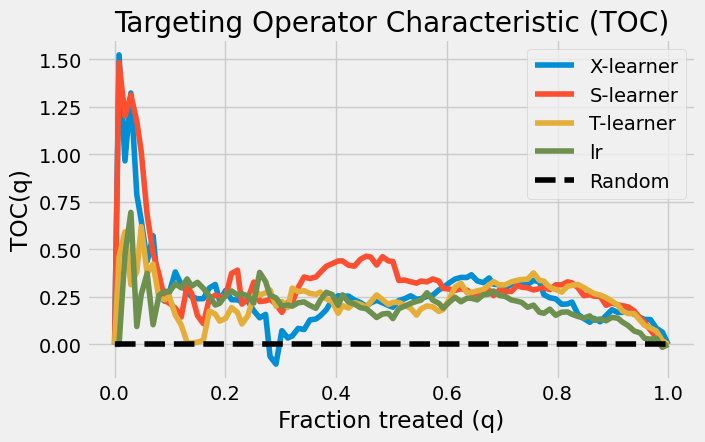

In [157]:
fig, ax = plt.subplots(figsize=(7, 4.2))
plot_toc(df_validation, outcome_col="y_true", treatment_col="w", ax=ax)

# Bibliography

Facure, Matheus. Causal Inference for the Brave and True. Online book, python-causality-handbook. Accessed 2026. https://matheusfacure.github.io/python-causality-handbook/

Hill, Jennifer L. "Bayesian Nonparametric Modeling for Causal Inference." Journal of Computational and Graphical Statistics 20, no. 1 (2011): 217–240. https://doi.org/10.1198/jcgs.2010.08162

Künzel, Sören R., Jasjeet S. Sekhon, Peter J. Bickel, and Bin Yu. "Metalearners for Estimating Heterogeneous Treatment Effects Using Machine Learning." Proceedings of the National Academy of Sciences 116, no. 10 (2019): 4156–4165. https://doi.org/10.1073/pnas.1804597116

Uber Technologies, Inc. "Estimating and Validating Heterogeneous Treatment Effects." CausalML Documentation. Accessed 2026. https://causalml.readthedocs.io/en/latest/tutorial.html